In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [3]:
df = pd.read_csv("customer_segmentation.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [7]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [8]:
df.drop(columns=["ID", "Kidhome", "Teenhome", "Z_CostContact", "Z_Revenue"], inplace=True, errors="ignore")

In [9]:
df["Age"] = 2026 - df["Year_Birth"]

In [10]:
df.drop(columns=["Year_Birth"], inplace=True, errors="ignore")

In [11]:
df["Total_Spending"] = (df["MntWines"] + 
df["MntFruits"]+
df["MntMeatProducts"]+
df["MntFishProducts"]+
df["MntSweetProducts"]+
df["MntGoldProds"])

In [12]:
df.drop(columns=["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"], inplace=True, errors="ignore")

In [13]:
df["Total Purchase"] = ( df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

In [14]:
#df.drop(columns=["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"], inplace=True, errors="ignore")

In [15]:
df["Campaign_Score"] = (
    df["AcceptedCmp1"] +
    df["AcceptedCmp2"] +
    df["AcceptedCmp3"] +
    df["AcceptedCmp4"] +
    df["AcceptedCmp5"] +
    df["Response"]
)

In [16]:
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)

In [17]:
df.drop(columns=["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"], inplace=True, errors="ignore")

In [18]:
df.head()

,Education,Marital_Status,Income,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Age,Total_Spending,Total Purchase,Campaign_Score,AcceptedAny
0,Graduation,Single,58138.0,04-09-2012,58,3,8,10,4,7,0,69,1617,22,1,1
1,Graduation,Single,46344.0,08-03-2014,38,2,1,1,2,5,0,72,27,4,0,0
2,Graduation,Together,71613.0,21-08-2013,26,1,8,2,10,4,0,61,776,20,0,0
3,Graduation,Together,26646.0,10-02-2014,26,2,2,0,4,6,0,42,53,6,0,0
4,PhD,Married,58293.0,19-01-2014,94,5,5,3,6,5,0,45,422,14,0,0


In [19]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst="True")
df["Customer_Tenure"] = (pd.Timestamp.today() - df["Dt_Customer"]).dt.days

In [20]:
df.head()

,Education,Marital_Status,Income,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Age,Total_Spending,Total Purchase,Campaign_Score,AcceptedAny,Customer_Tenure
0,Graduation,Single,58138.0,2012-09-04,58,3,8,10,4,7,0,69,1617,22,1,1,5103
1,Graduation,Single,46344.0,2014-03-08,38,2,1,1,2,5,0,72,27,4,0,0,4553
2,Graduation,Together,71613.0,2013-08-21,26,1,8,2,10,4,0,61,776,20,0,0,4752
3,Graduation,Together,26646.0,2014-02-10,26,2,2,0,4,6,0,42,53,6,0,0,4579
4,PhD,Married,58293.0,2014-01-19,94,5,5,3,6,5,0,45,422,14,0,0,4601


In [21]:
df[["Total_Spending"]]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


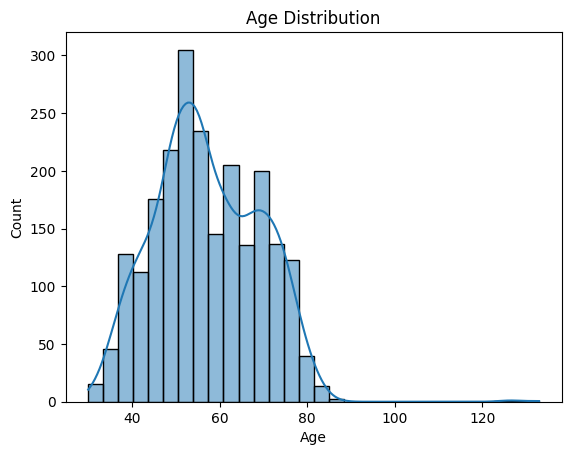

In [22]:
sns.histplot(df["Age"], bins = 30, kde=True)
plt.title("Age Distribution")
plt.show()

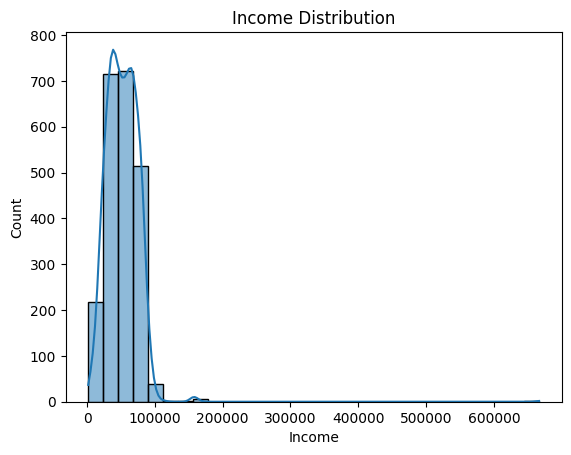

In [23]:
sns.histplot(df["Income"], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

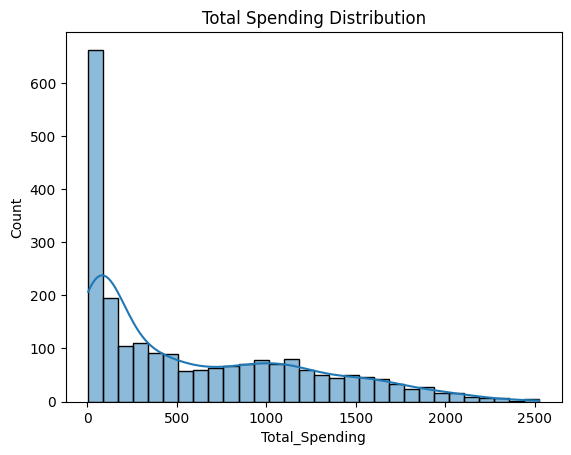

In [24]:
sns.histplot(df["Total_Spending"], bins=30, kde=True)
plt.title("Total Spending Distribution")
plt.show()

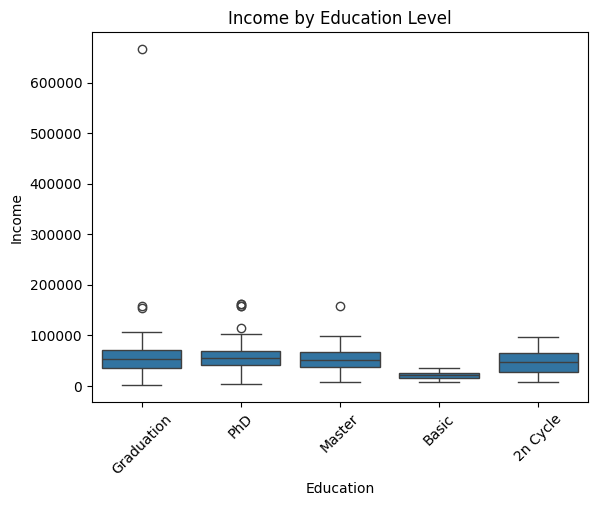

In [25]:
sns.boxplot(x="Education", y="Income", data = df)
plt.xticks(rotation = 45)
plt.title("Income by Education Level")
plt.show()

Text(0.5, 1.0, 'Spending by Marital Status')

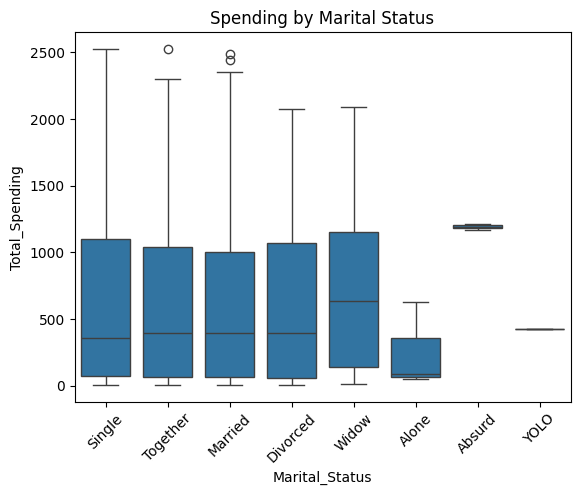

In [26]:
sns.boxplot(x="Marital_Status" , y="Total_Spending", data=df)
plt.xticks(rotation = 45)
plt.title("Spending by Marital Status")

In [27]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Dt_Customer', 'Recency',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Age',
       'Total_Spending', 'Total Purchase', 'Campaign_Score', 'AcceptedAny',
       'Customer_Tenure'],
      dtype='object')

In [28]:
corr = df[["Income","Age","Recency","Total_Spending","Total Purchase"]].corr()

In [29]:
corr

,Income,Age,Recency,Total_Spending,Total Purchase
Income,1.000000,0.161791,-0.003970,0.667576,0.625755
Age,0.161791,1.000000,0.019871,0.111306,0.162999
Recency,-0.003970,0.019871,1.000000,0.020433,0.006410
Total_Spending,0.667576,0.111306,0.020433,1.000000,0.820687
Total Purchase,0.625755,0.162999,0.006410,0.820687,1.000000


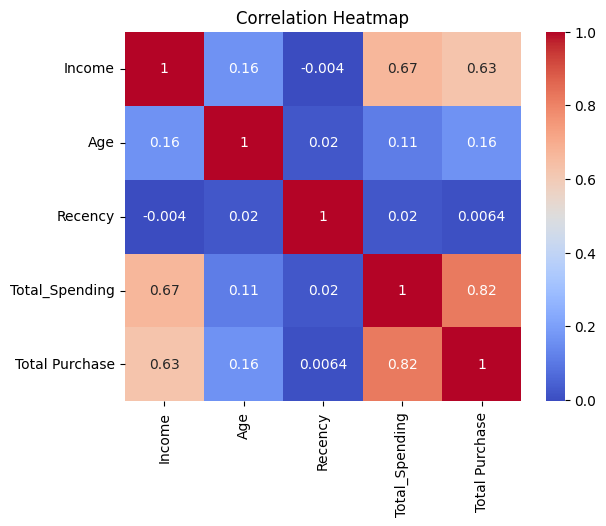

In [30]:
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [31]:
pivot_income = df.pivot_table(values = "Income", index="Education", columns="Marital_Status", aggfunc="mean")

In [32]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


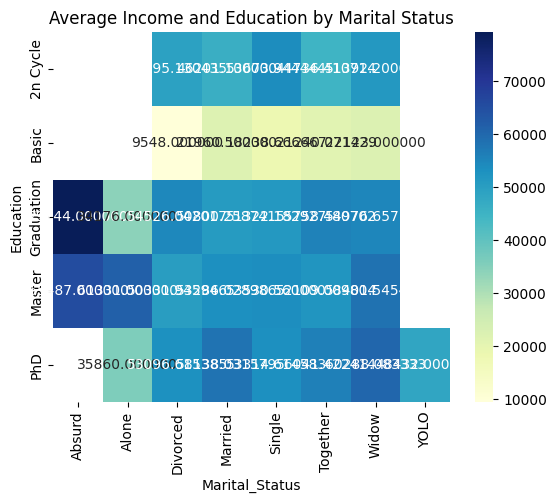

In [33]:
sns.heatmap(pivot_income, annot=True, fmt="0f", cmap="YlGnBu")
plt.title("Average Income and Education by Marital Status")
plt.show()

In [34]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending = False)

In [35]:
group1

Education
PhD           672.409465
Graduation    619.898846
Master        611.781081
2n Cycle      496.527094
Basic          81.796296
Name: Total_Spending, dtype: float64

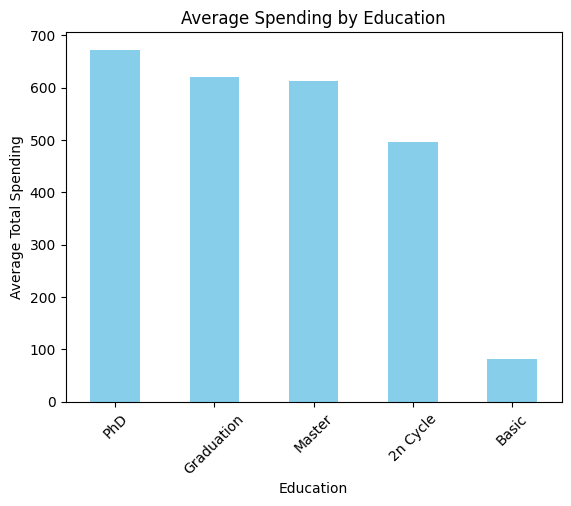

In [36]:
group1.plot(kind="bar", color="skyblue")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.show()

In [37]:
df.Campaign_Score

0       1
1       0
2       0
3       0
4       0
       ..
2235    0
2236    1
2237    1
2238    0
2239    1
Name: Campaign_Score, Length: 2240, dtype: int64

In [38]:
#df["AcceptedAny"]

In [39]:
#df["AcceptedAny"].unique()

In [40]:
df["Campaign_Score"].unique()

array([1, 0, 3, 2, 4, 5])

In [41]:
df["Campaign_Score"] = df["Campaign_Score"].apply([lambda x: 1 if x>0 else 0])

In [42]:
df["Campaign_Score"].unique()

array([1, 0])

In [43]:
group2 = df.groupby("Marital_Status")["Campaign_Score"].mean().sort_values(ascending=False)

In [44]:
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.350649
Alone       0.333333
Single      0.308333
Divorced    0.297414
Married     0.251157
Together    0.250000
Name: Campaign_Score, dtype: float64

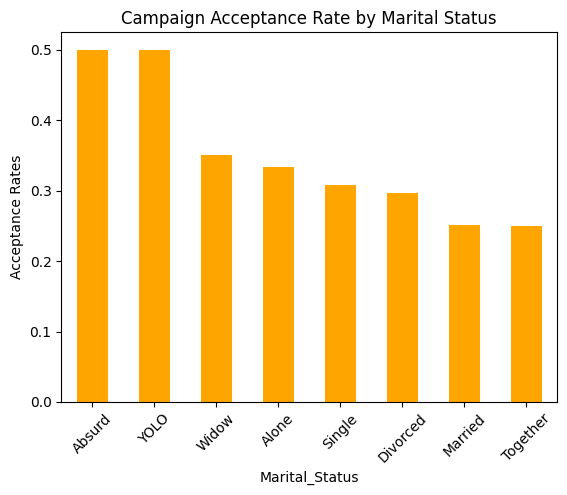

In [45]:
group2.plot(kind="bar", color="orange")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Acceptance Rates")
plt.xticks(rotation=45)
plt.show()

In [46]:
bins = [18, 30, 40, 50, 60, 70, 90]

In [47]:
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]

In [48]:
df["AgeGroup"] = pd.cut(df["Age"], bins = bins, labels = labels)

In [49]:
df["AgeGroup"]


0       60-69
1         70+
2       60-69
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2240, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [50]:
group3 = df.groupby("AgeGroup")["Income"].mean()

C:\Users\anush\AppData\Local\Temp\ipykernel_27808\1140876350.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby("AgeGroup")["Income"].mean()


In [51]:
group3

AgeGroup
18-29    10960.500000
30-39    47905.475676
40-49    48057.587649
50-59    50479.321534
60-69    55980.030928
70+      58767.083102
Name: Income, dtype: float64

Text(0.5, 0, 'Average Income')

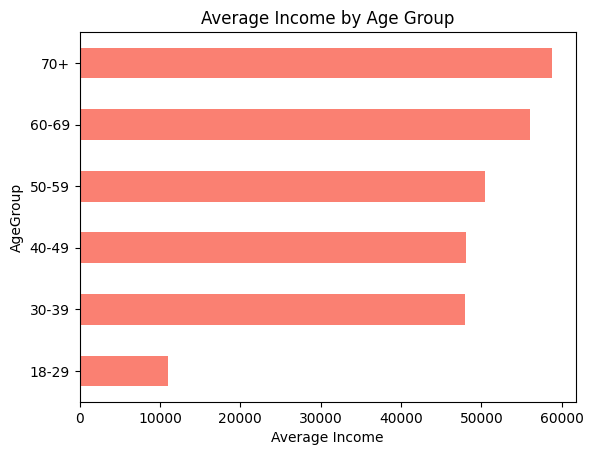

In [52]:
group3.plot(kind="barh", color="salmon")
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")

In [53]:
df.head()

,Education,Marital_Status,Income,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Age,Total_Spending,Total Purchase,Campaign_Score,AcceptedAny,Customer_Tenure,AgeGroup
0,Graduation,Single,58138.0,2012-09-04,58,3,8,10,4,7,0,69,1617,22,1,1,5103,60-69
1,Graduation,Single,46344.0,2014-03-08,38,2,1,1,2,5,0,72,27,4,0,0,4553,70+
2,Graduation,Together,71613.0,2013-08-21,26,1,8,2,10,4,0,61,776,20,0,0,4752,60-69
3,Graduation,Together,26646.0,2014-02-10,26,2,2,0,4,6,0,42,53,6,0,0,4579,40-49
4,PhD,Married,58293.0,2014-01-19,94,5,5,3,6,5,0,45,422,14,0,0,4601,40-49


In [54]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Dt_Customer', 'Recency',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Age',
       'Total_Spending', 'Total Purchase', 'Campaign_Score', 'AcceptedAny',
       'Customer_Tenure', 'AgeGroup'],
      dtype='object')

In [55]:
features = ["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]

In [56]:
features

['Age',
 'Income',
 'Total_Spending',
 'NumWebPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Recency']

In [57]:
X = df[features].copy()

In [58]:
X  

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,69,58138.0,1617,8,4,7,58
1,72,46344.0,27,1,2,5,38
2,61,71613.0,776,8,10,4,26
3,42,26646.0,53,2,4,6,26
4,45,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,59,61223.0,1341,9,4,5,46
2236,80,64014.0,444,8,5,7,56
2237,45,56981.0,1241,2,13,6,91
2238,70,69245.0,843,6,10,3,8


In [59]:
df = df.loc[X.index].copy()

In [98]:
features = [
    "Age",
    "Income",
    "Total_Spending",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Recency"
]

X = df[features].copy()

print("\nFeatures Used for Clustering:")
print(features)

print("\nFeature Matrix Shape:")
print(X.shape)



Features Used for Clustering:
['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']

Feature Matrix Shape:
(2240, 7)


In [99]:
X_train, X_test = train_test_split(
    X,
    test_size=0.20,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (1792, 7)
Testing Shape : (448, 7)


In [100]:
imputer = SimpleImputer(
    strategy="mean"
)

X_train_imputed = imputer.fit_transform(X_train)

X_test_imputed = imputer.transform(X_test)


In [101]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_imputed
)

X_test_scaled = scaler.transform(
    X_test_imputed
)

In [102]:
k_values = range(2, 11)

silhouette_scores = []
davies_scores = []
calinski_scores = []
wcss = []


for k in k_values:

    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=42
    )

    labels = model.fit_predict(
        X_train_scaled
    )

    # WCSS
    wcss.append(
        model.inertia_
    )

    # Silhouette Score
    silhouette_scores.append(
        silhouette_score(
            X_train_scaled,
            labels
        )
    )

    # Davies-Bouldin Index
    davies_scores.append(
        davies_bouldin_score(
            X_train_scaled,
            labels
        )
    )

    # Calinski-Harabasz Score
    calinski_scores.append(
        calinski_harabasz_score(
            X_train_scaled,
            labels
        )
    )


In [106]:
evaluation_df = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_scores,
    "Davies-Bouldin Index": davies_scores,
    "Calinski-Harabasz Score": calinski_scores
})

print("CLUSTER NUMBER EVALUATION")
print(
    evaluation_df.round(4)
)


CLUSTER NUMBER EVALUATION
    K  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Score
0   2            0.3240                1.2872                 916.0277
1   3            0.2680                1.6906                 630.3370
2   4            0.1912                1.7820                 524.2518
3   5            0.1900                1.7478                 458.9106
4   6            0.1918                1.4622                 433.8388
5   7            0.1879                1.3716                 411.5756
6   8            0.1866                1.4352                 389.3215
7   9            0.1880                1.3907                 370.0231
8  10            0.1897                1.3936                 352.0469


In [104]:
best_k = list(k_values)[
    np.argmax(silhouette_scores)
]

best_silhouette = max(
    silhouette_scores
)

print("\nBest K based on Silhouette Score:", best_k)

print(
    "Best Silhouette Score:",
    round(best_silhouette, 4)
)


Best K based on Silhouette Score: 2
Best Silhouette Score: 0.324


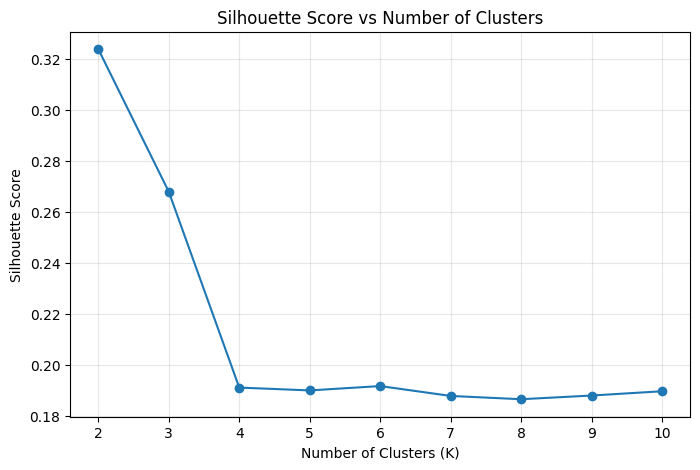

In [107]:

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")

plt.xticks(list(k_values))

plt.grid(alpha=0.3)

plt.show()



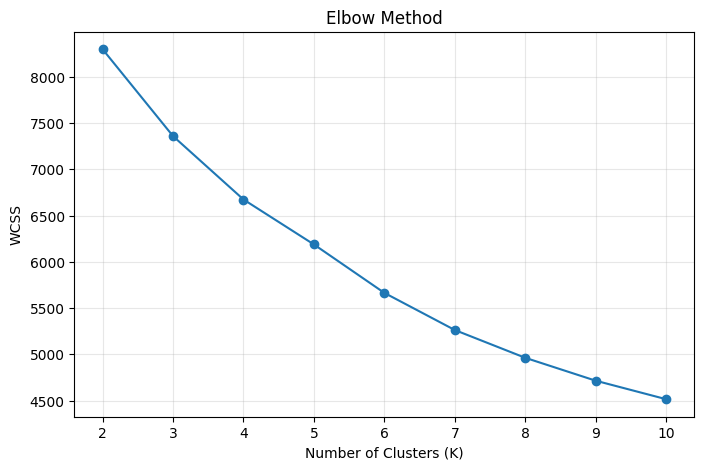

In [108]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.xticks(list(k_values))

plt.grid(alpha=0.3)

plt.show()



In [109]:
kmeans = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

train_clusters = kmeans.fit_predict(
    X_train_scaled
)

test_clusters = kmeans.predict(
    X_test_scaled
)


In [110]:
train_silhouette = silhouette_score(
    X_train_scaled,
    train_clusters
)

train_davies = davies_bouldin_score(
    X_train_scaled,
    train_clusters
)

train_calinski = calinski_harabasz_score(
    X_train_scaled,
    train_clusters
)

In [111]:
test_silhouette = silhouette_score(
    X_test_scaled,
    test_clusters
)

test_davies = davies_bouldin_score(
    X_test_scaled,
    test_clusters
)

test_calinski = calinski_harabasz_score(
    X_test_scaled,
    test_clusters
)



In [112]:
print("\n==========================================")
print("        FINAL K-MEANS EVALUATION")
print("==========================================")

print("\nSelected K:", best_k)

print("\nTraining Metrics:")
print("------------------------------------------")

print(
    "Silhouette Score      :",
    round(train_silhouette, 4)
)

print(
    "Davies-Bouldin Index  :",
    round(train_davies, 4)
)

print(
    "Calinski-Harabasz     :",
    round(train_calinski, 4)
)


print("\nTesting Metrics:")
print("------------------------------------------")

print(
    "Silhouette Score      :",
    round(test_silhouette, 4)
)

print(
    "Davies-Bouldin Index  :",
    round(test_davies, 4)
)

print(
    "Calinski-Harabasz     :",
    round(test_calinski, 4)
)




        FINAL K-MEANS EVALUATION

Selected K: 2

Training Metrics:
------------------------------------------
Silhouette Score      : 0.324
Davies-Bouldin Index  : 1.2872
Calinski-Harabasz     : 916.0277

Testing Metrics:
------------------------------------------
Silhouette Score      : 0.2893
Davies-Bouldin Index  : 1.3766
Calinski-Harabasz     : 213.0205


In [113]:
print("\nTraining Cluster Distribution:")
print(
    pd.Series(train_clusters)
    .value_counts()
    .sort_index()
)

print("\nTesting Cluster Distribution:")
print(
    pd.Series(test_clusters)
    .value_counts()
    .sort_index()
)




Training Cluster Distribution:
0    843
1    949
Name: count, dtype: int64

Testing Cluster Distribution:
0    227
1    221
Name: count, dtype: int64


In [114]:
X_full_imputed = imputer.fit_transform(X)

X_full_scaled = scaler.fit_transform(
    X_full_imputed
)

final_kmeans = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

df["Cluster"] = final_kmeans.fit_predict(
    X_full_scaled
)

In [115]:
cluster_summary = (
    df.groupby("Cluster")[features]
    .mean()
)

print("\n==========================================")
print("          FINAL CLUSTER SUMMARY")
print("==========================================")

print(
    cluster_summary.round(2)
)



          FINAL CLUSTER SUMMARY
           Age    Income  Total_Spending  NumWebPurchases  NumStorePurchases  \
Cluster                                                                        
0        59.48  70301.37         1119.75             5.81               8.36   
1        55.11  35692.44          135.78             2.50               3.44   

         NumWebVisitsMonth  Recency  
Cluster                              
0                     3.98    49.37  
1                     6.54    48.87  


In [116]:
print("\nFinal Cluster Distribution:")

print(
    df["Cluster"]
    .value_counts()
    .sort_index()
)



Final Cluster Distribution:
Cluster
0    1070
1    1170
Name: count, dtype: int64


In [117]:
if best_k == 2:

    cluster_names = {
        0: "High Value Customers",
        1: "Low Value Customers"
    }

    df["Cluster_Name"] = (
        df["Cluster"]
        .map(cluster_names)
    )

In [118]:
pca = PCA(
    n_components=2
)

pca_data = pca.fit_transform(
    X_full_scaled
)

df["PCA1"] = pca_data[:, 0]

df["PCA2"] = pca_data[:, 1]


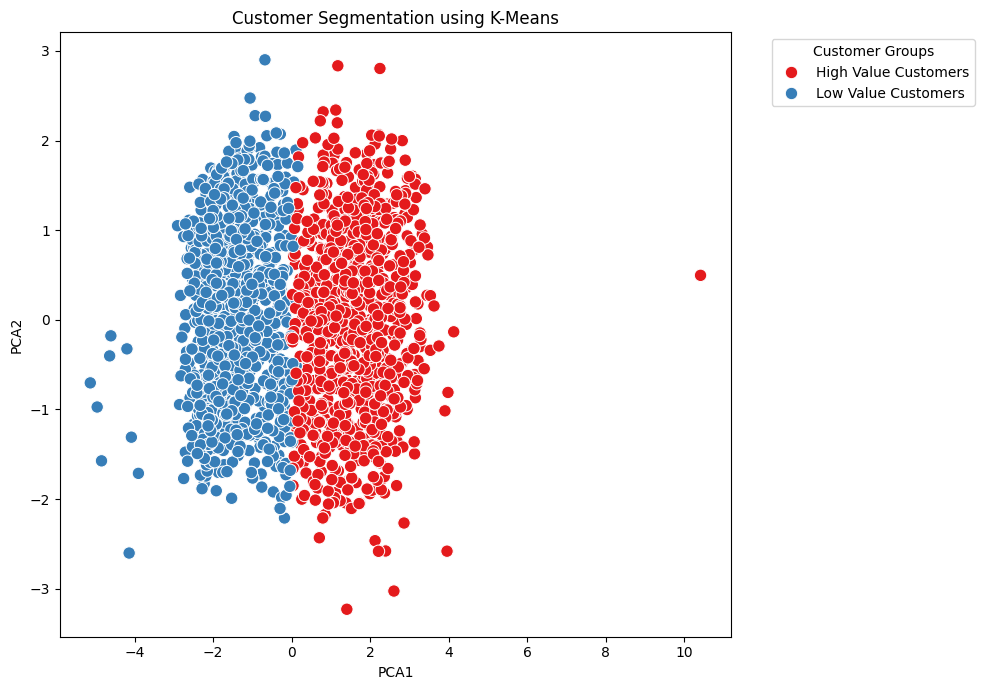

In [119]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster_Name",
    data=df,
    palette="Set1",
    s=80
)

plt.title(
    "Customer Segmentation using K-Means"
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.legend(
    title="Customer Groups",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [121]:
joblib.dump(
    final_kmeans,
    "kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    imputer,
    "imputer.pkl"
)

joblib.dump(
    features,
    "features.pkl"
)

['features.pkl']

In [122]:
print("kmeans_model.pkl")
print("scaler.pkl")
print("imputer.pkl")
print("features.pkl")

kmeans_model.pkl
scaler.pkl
imputer.pkl
features.pkl
